# **Librerias** 


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Funciones

In [3]:
%matplotlib inline

def EDA(data):
    # Definir variables para el análisis
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    categorical_cols = data.select_dtypes(include=['object']).columns

    print(f'Variables numéricas: {numeric_cols}')
    print(f'Variables categóricas: {categorical_cols}')

    # Crear figura con 3 columnas (Histograma, Boxplot, Violin) y 4 filas (una por cada variable)
    fig, axes = plt.subplots(len(numeric_cols), 3, figsize=(18, 5*len(numeric_cols)))
    fig.suptitle('ANÁLISIS EXPLORATORIO: Histograma, Boxplot y Violin Plot', 
                fontsize=16, fontweight='bold', y=0.995)

    for idx, col in enumerate(numeric_cols):
        # HISTOGRAMA
        axes[idx, 0].hist(data[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
        axes[idx, 0].set_title(f'Histograma: {col}', fontweight='bold')
        axes[idx, 0].set_xlabel('Valor')
        axes[idx, 0].set_ylabel('Frecuencia')
        axes[idx, 0].grid(axis='y', alpha=0.3)
        
        # BOXPLOT
        axes[idx, 1].boxplot(data[col].dropna(), vert=True, patch_artist=True,
                            boxprops=dict(facecolor='lightblue', alpha=0.7),
                            medianprops=dict(color='red', linewidth=2))
        axes[idx, 1].set_title(f'Boxplot: {col}', fontweight='bold')
        axes[idx, 1].set_ylabel('Valor')
        axes[idx, 1].grid(axis='y', alpha=0.3)
        
        # VIOLIN PLOT
        parts = axes[idx, 2].violinplot(data[col].dropna(), vert=True, showmeans=True, showmedians=True)
        axes[idx, 2].set_title(f'Violin Plot: {col}', fontweight='bold')
        axes[idx, 2].set_ylabel('Valor')
        axes[idx, 2].grid(axis='y', alpha=0.3)

    plt.tight_layout()

    plt.show()

    

    print('='*80)
    print('ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS')
    print('='*80)
    print()
    print(data[numeric_cols].describe().to_string())

    print('\n' + '='*80)
    print('ANÁLISIS DETALLADO POR VARIABLE')
    print('='*80)

    for col in numeric_cols:
        print(f'\n📊 {col}')
        print(f'   Media: {data[col].mean():.4f}')
        print(f'   Mediana: {data[col].median():.4f}')
        print(f'   Desv. Estándar: {data[col].std():.4f}')
        print(f'   Mínimo: {data[col].min():.4f}')
        print(f'   Máximo: {data[col].max():.4f}')
        print(f'   Q1 (25%): {data[col].quantile(0.25):.4f}')
        print(f'   Q3 (75%): {data[col].quantile(0.75):.4f}')
        print(f'   IQR: {data[col].quantile(0.75) - data[col].quantile(0.25):.4f}')
        print(f'   Asimetría (Skewness): {stats.skew(data[col].dropna()):.4f}')
        print(f'   Curtosis (Kurtosis): {stats.kurtosis(data[col].dropna()):.4f}')

    # Calcular matriz de correlación
    correlation_matrix = data[numeric_cols].corr()

    print('='*80)
    print('MATRIZ DE CORRELACIÓN (PEARSON)')
    print('='*80)
    print(correlation_matrix.to_string())

    # Visualizar matriz de correlación
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={'shrink': 0.8}, ax=ax,
                vmin=-1, vmax=1)
    ax.set_title('MATRIZ DE CORRELACIÓN DE PEARSON\nVariables Numéricas', 
                fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    
    plt.show()

    

    print('='*80)
    print('CORRELACIONES POR PARES - ANÁLISIS DETALLADO')
    print('='*80)

    correlations_list = []
    for i in range(len(numeric_cols)):
        for j in range(i+1, len(numeric_cols)):
            col1, col2 = numeric_cols[i], numeric_cols[j]
            
            # Pearson
            pearson_r, pearson_p = stats.pearsonr(data[col1].dropna(), data[col2].dropna())
            
            # Spearman
            spearman_r, spearman_p = stats.spearmanr(data[col1].dropna(), data[col2].dropna())
            
            correlations_list.append({
                'Variable 1': col1[:35],
                'Variable 2': col2[:35],
                'Pearson r': round(pearson_r, 4),
                'Pearson p-value': round(pearson_p, 6),
                'Spearman r': round(spearman_r, 4),
                'Spearman p-value': round(spearman_p, 6)
            })

    corr_results = pd.DataFrame(correlations_list).sort_values('Pearson p-value')
    print()
    print(corr_results.to_string(index=False))

    # Identificar correlaciones significativas
    print('\n' + '='*80)
    print('CORRELACIONES SIGNIFICATIVAS (p < 0.05)')
    print('='*80)
    significant = corr_results[corr_results['Pearson p-value'] < 0.05]
    if len(significant) > 0:
        print(significant.to_string(index=False))
    else:
        print('No se encontraron correlaciones significativas al nivel p < 0.05')

    # Crear scatter plots para todas las correlaciones
    n_pairs = len(correlations_list)
    n_cols = 2
    n_rows = (n_pairs + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle('SCATTER PLOTS - Correlaciones entre Variables Numéricas', 
                fontweight='bold', fontsize=14)

    for idx, row in enumerate(correlations_list):
        ax = axes[idx // n_cols, idx % n_cols]
        
        col1_name = row['Variable 1']
        col2_name = row['Variable 2']
        
        # Encontrar columnas originales completas
        col1 = [c for c in numeric_cols if col1_name in c][0]
        col2 = [c for c in numeric_cols if col2_name in c][0]
        
        # Scatter plot
        ax.scatter(data[col1], data[col2], alpha=0.6, s=50, color='steelblue', 
                edgecolor='black', linewidth=0.5)
        
        # Línea de tendencia
        z = np.polyfit(data[col1].dropna(), data[col2].dropna(), 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[col1].min(), data[col1].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.8, label='Línea de tendencia')
        
        ax.set_xlabel(col1[:30], fontweight='bold')
        ax.set_ylabel(col2[:30], fontweight='bold')
        ax.set_title(f'r = {row["Pearson r"]:.3f} (p={row["Pearson p-value"]:.4f})', 
                    fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend()

    # Ocultar subplots vacíos
    for idx in range(n_pairs, n_rows*n_cols):
        axes[idx // n_cols, idx % n_cols].set_visible(False)

    plt.tight_layout()
    
    plt.show()

   

    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(5*len(categorical_cols), 5))
    fig.suptitle('DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS', fontweight='bold', fontsize=14)

    for idx, col in enumerate(categorical_cols):
        value_counts = data[col].value_counts()
        colors = sns.color_palette('husl', len(value_counts))
        
        axes[idx].barh(value_counts.index, value_counts.values, color=colors, 
                    alpha=0.8, edgecolor='black', linewidth=1.5)
        axes[idx].set_title(f'{col}', fontweight='bold', fontsize=12)
        axes[idx].set_xlabel('Frecuencia', fontweight='bold')
        
        # Agregar valores en las barras
        for i, v in enumerate(value_counts.values):
            axes[idx].text(v + 0.5, i, str(v), va='center', fontweight='bold')
        
        print(f'\n{col}:')
        print(value_counts.to_string())

    plt.tight_layout()
    
    plt.show()

    

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Variables Numéricas por Color Test de Predominancia', 
                fontweight='bold', fontsize=14)

    for idx, col in enumerate(numeric_cols):
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]
        
        sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax, 
                palette='Set2', linewidth=2)
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Color Test', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    plt.show()

    

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Variables Numéricas por Semestre-Grupo', 
                fontweight='bold', fontsize=14)

    for idx, col in enumerate(numeric_cols):
        row = idx // 2
        col_idx = idx % 2
        ax = axes[row, col_idx]
        
        sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax, 
                    palette='muted')
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('Semestre-Grupo', fontweight='bold')
        ax.set_ylabel('Valor', fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    
    plt.show()
    plt.close('all')



# Datos

In [4]:
dataset_raw = pd.read_csv('Datos_Test_Semestres_analisis.csv')

## Tratamiento de faltantes

In [5]:
dataset_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   EQ.                                    536 non-null    int64  
 1   ID                                     536 non-null    object 
 2   Trabajo en Equipo 
(con factor) (50%)  536 non-null    float64
 3   Trabajo en Equipo 
(sin factor)        531 non-null    float64
 4   Co-evaluación                          536 non-null    float64
 5   Color Test de predominancia            509 non-null    object 
 6   CARRERA                                536 non-null    object 
 7   Etiqueta Semestre-Grupo                536 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 33.6+ KB


In [6]:
#Identificar Estudiantes con 0 en Trabajo en Equipo para eliminarlos del análisis
Est_0 = dataset_raw[dataset_raw['Trabajo en Equipo \n(con factor) (50%)'] == 0]
dataset_raw.drop(Est_0.index, inplace=True)

In [7]:
#Tratamiento de Nan en la columna de Test de Predominancia, asignando el tipo de test que menos se repite en el equipo al que pertenece el estudiante, o el que no se repite si es el caso.
test_values = dataset_raw['Color Test de predominancia'].dropna().unique().tolist()

test_Nan = dataset_raw[dataset_raw['Color Test de predominancia'].isna()]

teams_with_Nan = list(zip(test_Nan['ID'], test_Nan['EQ.'], test_Nan['Etiqueta Semestre-Grupo']))

for team in teams_with_Nan:
    team_data = dataset_raw[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2])]
    type_count = team_data['Color Test de predominancia'].value_counts()
    
    for i, type in enumerate(test_values):
        if type not in type_count.index: 
           dataset_raw.loc[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2]) & (dataset_raw['Color Test de predominancia'].isna()), 'Color Test de predominancia'] = type
           break
        if i == len(test_values) - 1: 
           dataset_raw.loc[(dataset_raw['EQ.'] == team[1]) & (dataset_raw['Etiqueta Semestre-Grupo'] == team[2]) & (dataset_raw['Color Test de predominancia'].isna()), 'Color Test de predominancia'] = type_count.idxmin()

In [8]:
for column in dataset_raw.columns:
    print(f"Columna '{column}' tiene {dataset_raw[column].isna().sum()} valores faltantes.")    

Columna 'EQ.' tiene 0 valores faltantes.
Columna 'ID' tiene 0 valores faltantes.
Columna 'Trabajo en Equipo 
(con factor) (50%)' tiene 0 valores faltantes.
Columna 'Trabajo en Equipo 
(sin factor)' tiene 0 valores faltantes.
Columna 'Co-evaluación' tiene 0 valores faltantes.
Columna 'Color Test de predominancia' tiene 0 valores faltantes.
Columna 'CARRERA' tiene 0 valores faltantes.
Columna 'Etiqueta Semestre-Grupo' tiene 0 valores faltantes.


## EDA (Individual)

Variables numéricas: Index(['EQ.', 'Trabajo en Equipo \n(con factor) (50%)',
       'Trabajo en Equipo \n(sin factor)', 'Co-evaluación'],
      dtype='object')
Variables categóricas: Index(['Color Test de predominancia', 'Etiqueta Semestre-Grupo'], dtype='object')


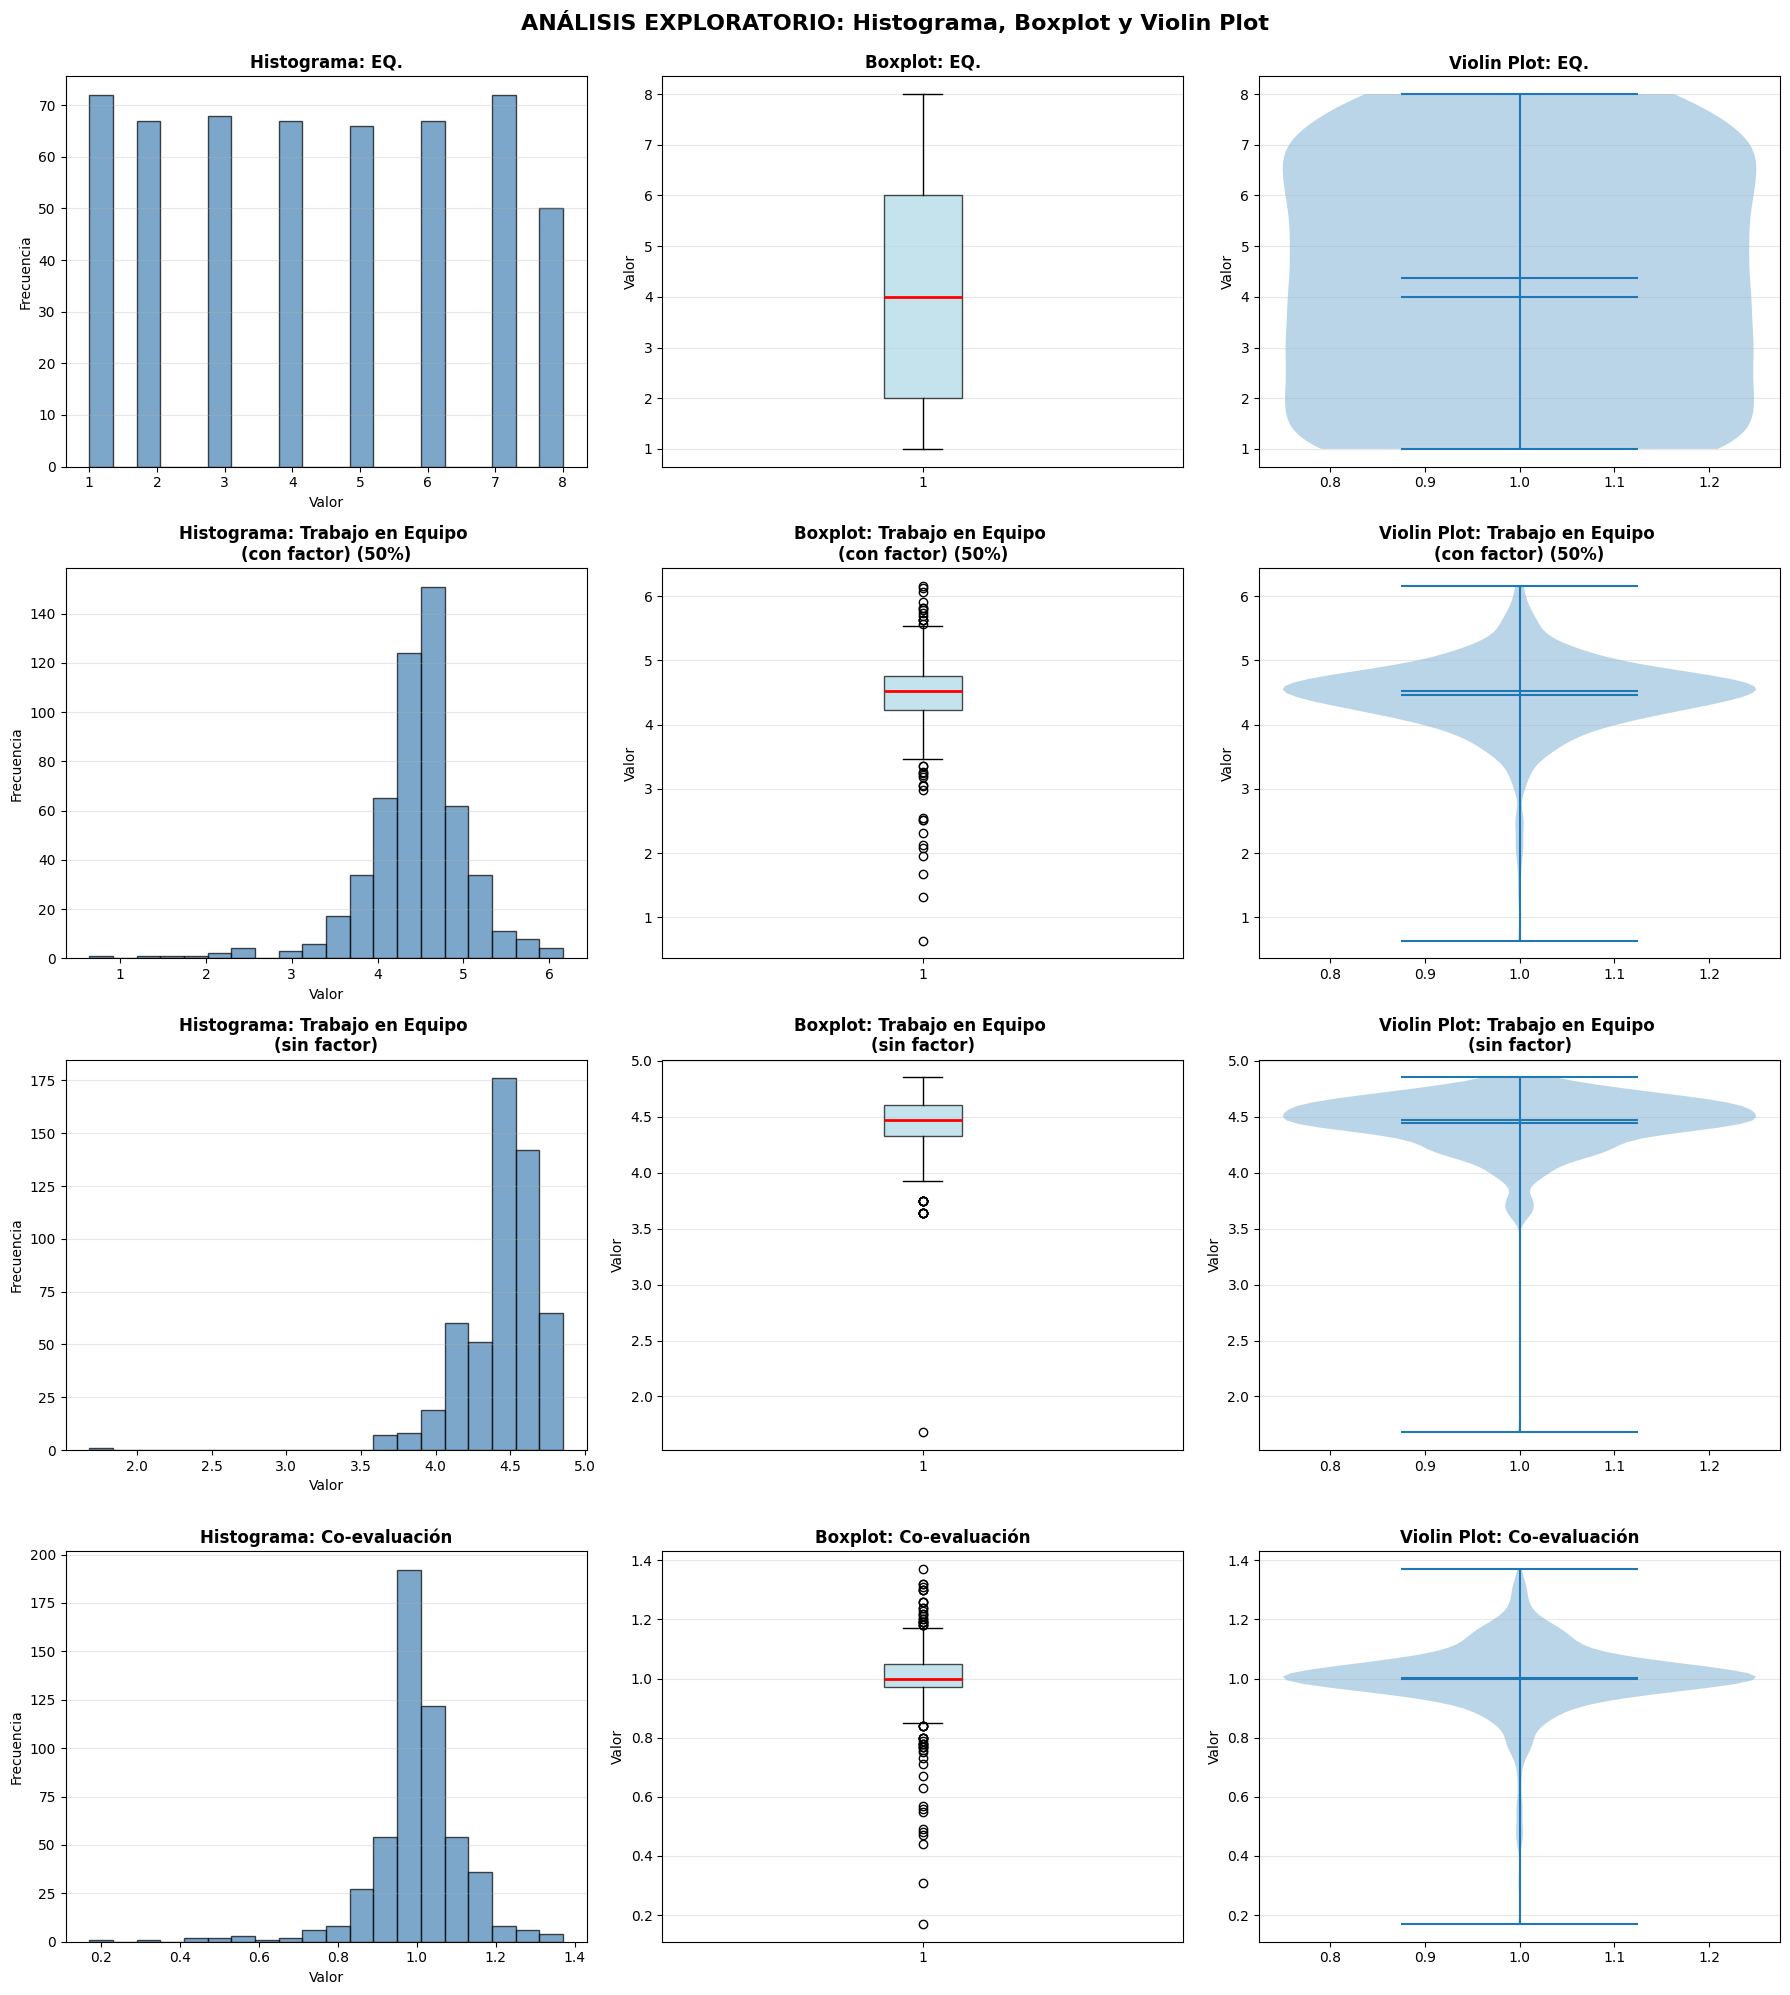

ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

              EQ.  Trabajo en Equipo \n(con factor) (50%)  Trabajo en Equipo \n(sin factor)  Co-evaluación
count  529.000000                              529.000000                        529.000000     529.000000
mean     4.374291                                4.459395                          4.444063       1.003310
std      2.257936                                0.593460                          0.262422       0.120387
min      1.000000                                0.640000                          1.680000       0.170000
25%      2.000000                                4.220000                          4.327915       0.970000
50%      4.000000                                4.520000                          4.475767       1.000000
75%      6.000000                                4.750000                          4.609235       1.050000
max      8.000000                                6.160000                          4.852667   

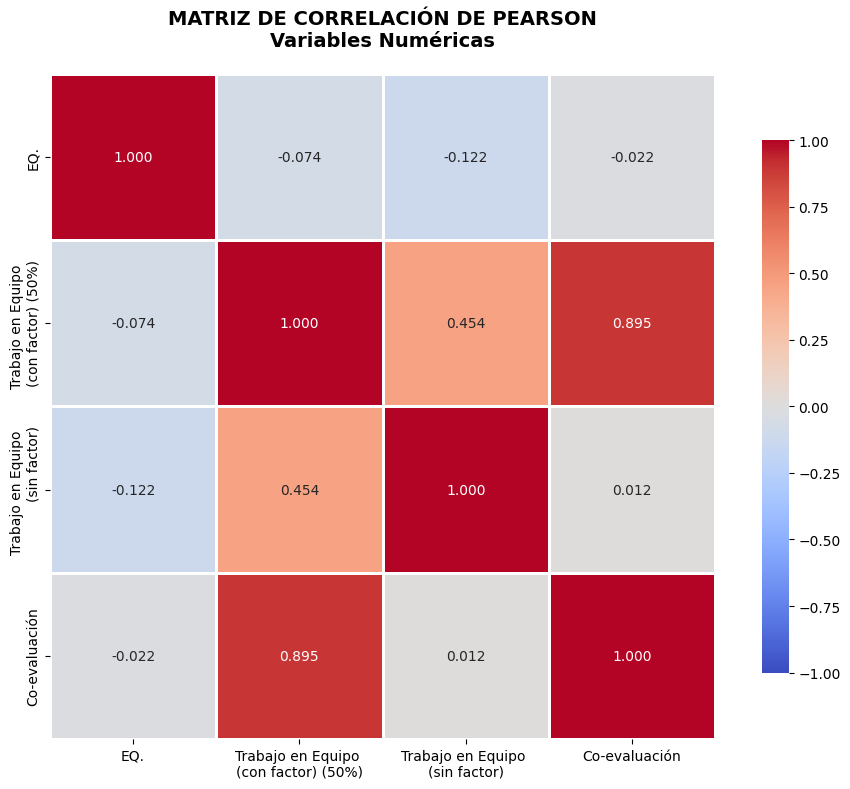

CORRELACIONES POR PARES - ANÁLISIS DETALLADO

                          Variable 1                           Variable 2  Pearson r  Pearson p-value  Spearman r  Spearman p-value
Trabajo en Equipo \n(con factor) (50     Trabajo en Equipo \n(sin factor)     0.4537         0.000000      0.4906          0.000000
Trabajo en Equipo \n(con factor) (50                        Co-evaluación     0.8949         0.000000      0.8068          0.000000
                                 EQ.     Trabajo en Equipo \n(sin factor)    -0.1223         0.004856     -0.1289          0.002969
                                 EQ. Trabajo en Equipo \n(con factor) (50    -0.0742         0.088074     -0.0744          0.087276
                                 EQ.                        Co-evaluación    -0.0217         0.618397     -0.0014          0.974040
    Trabajo en Equipo \n(sin factor)                        Co-evaluación     0.0123         0.777888     -0.0192          0.659975

CORRELACIONES SIGNIFICATIVAS 

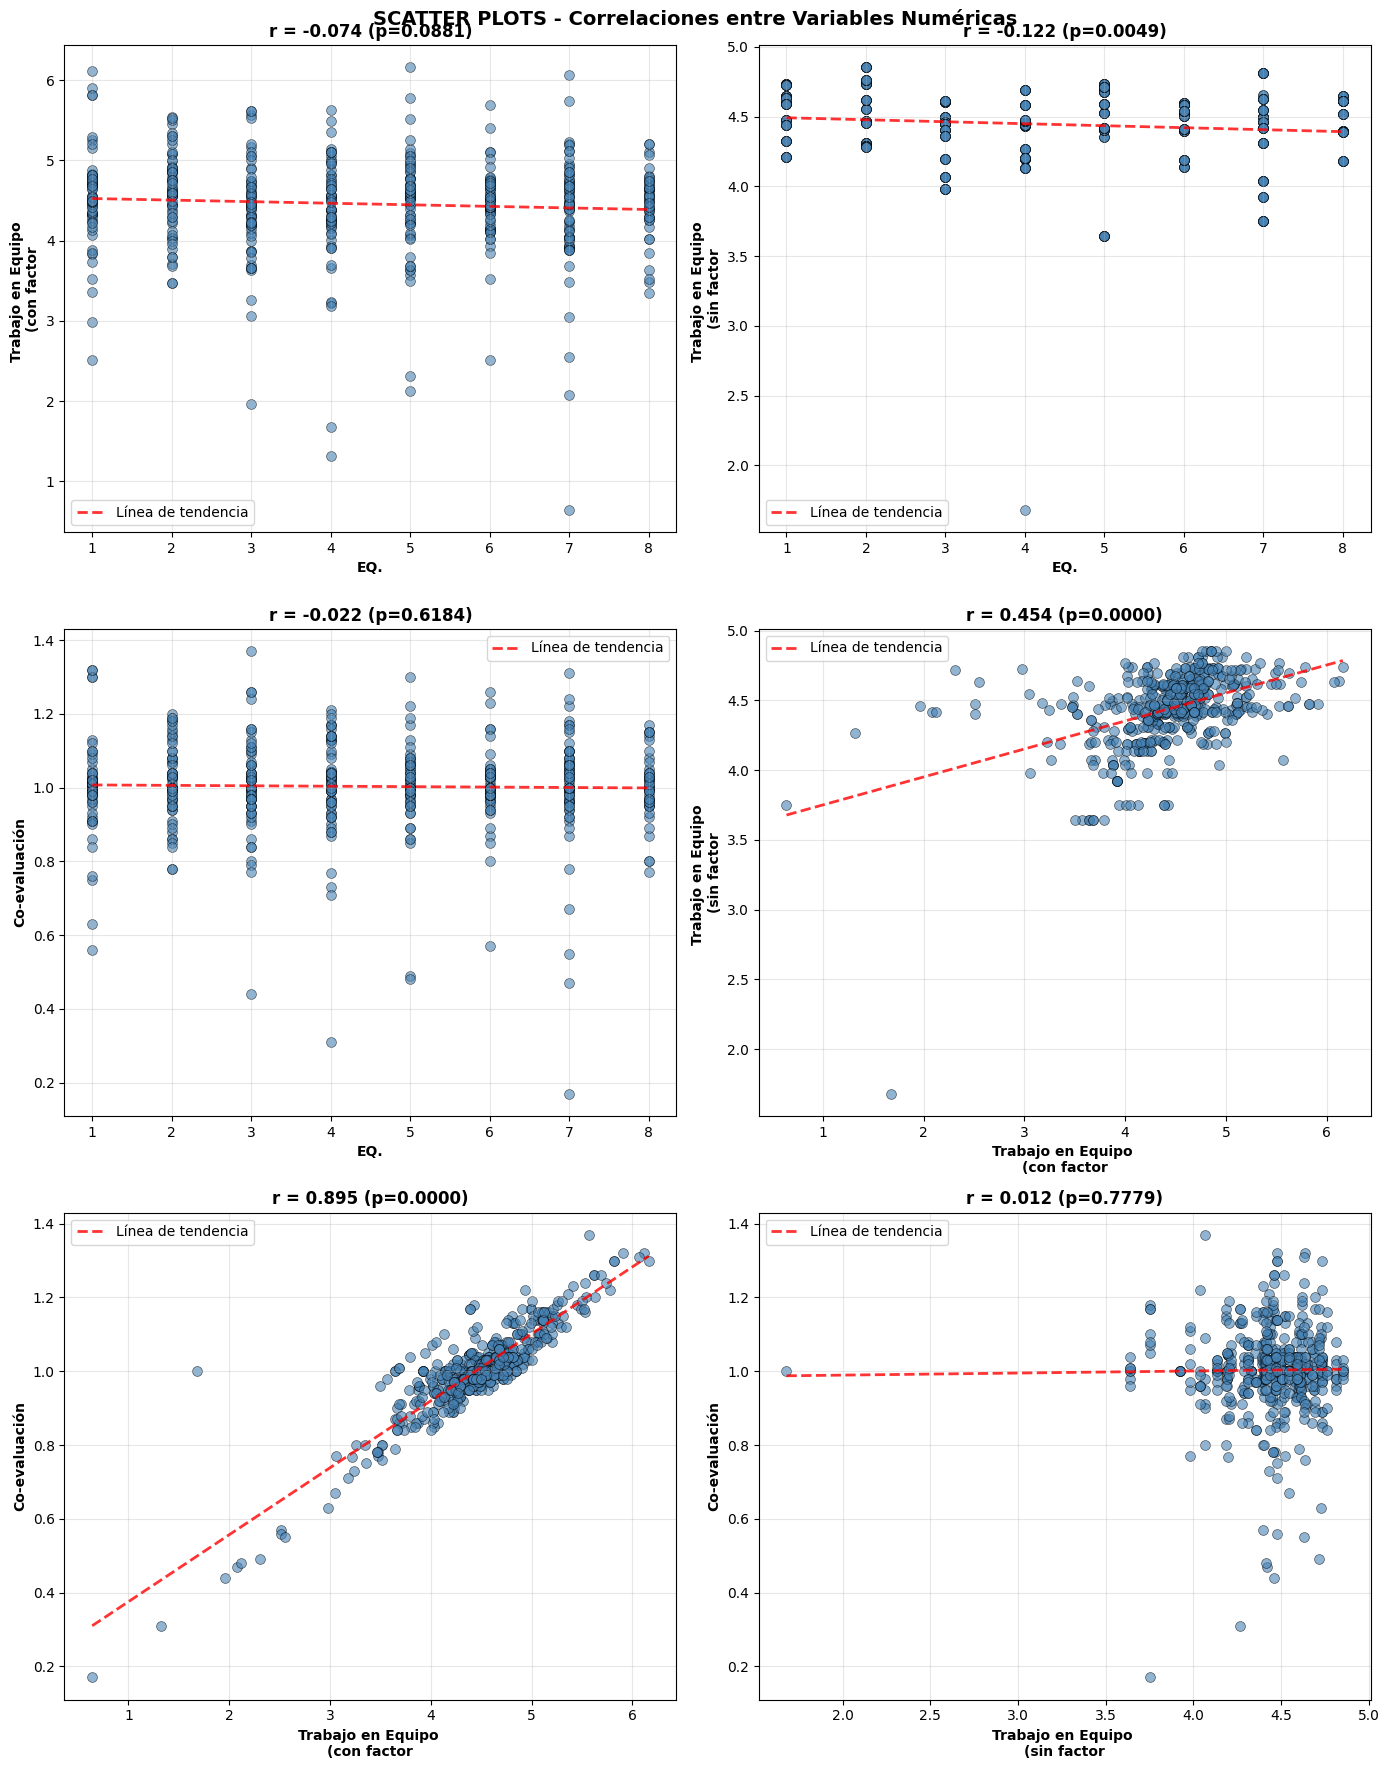


Color Test de predominancia:
Color Test de predominancia
Tipo A - Azul       251
Tipo B - Verde      143
Tipo C - Rojo        74
Tipo D - Naranja     61

Etiqueta Semestre-Grupo:
Etiqueta Semestre-Grupo
2023-02-G3       59
2023-01-G3       58
2024-02-G3       57
2024-01-G3       57
2022-02-G3       54
2021-01-G7       51
2021-02-G3-G7    49
2022-01-G3       49
2025-01-G3       49
2025-02-G3       46


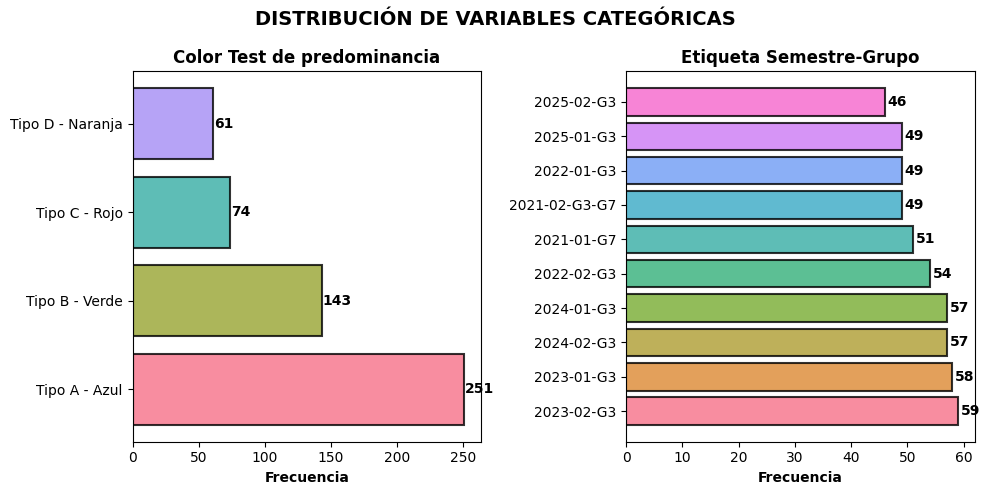

C:\Users\osqui\AppData\Local\Temp\ipykernel_11176\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_11176\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_11176\2893191598.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Color Test de predominancia', y=col, ax=ax,
C:\Users\osqui\AppData\Local

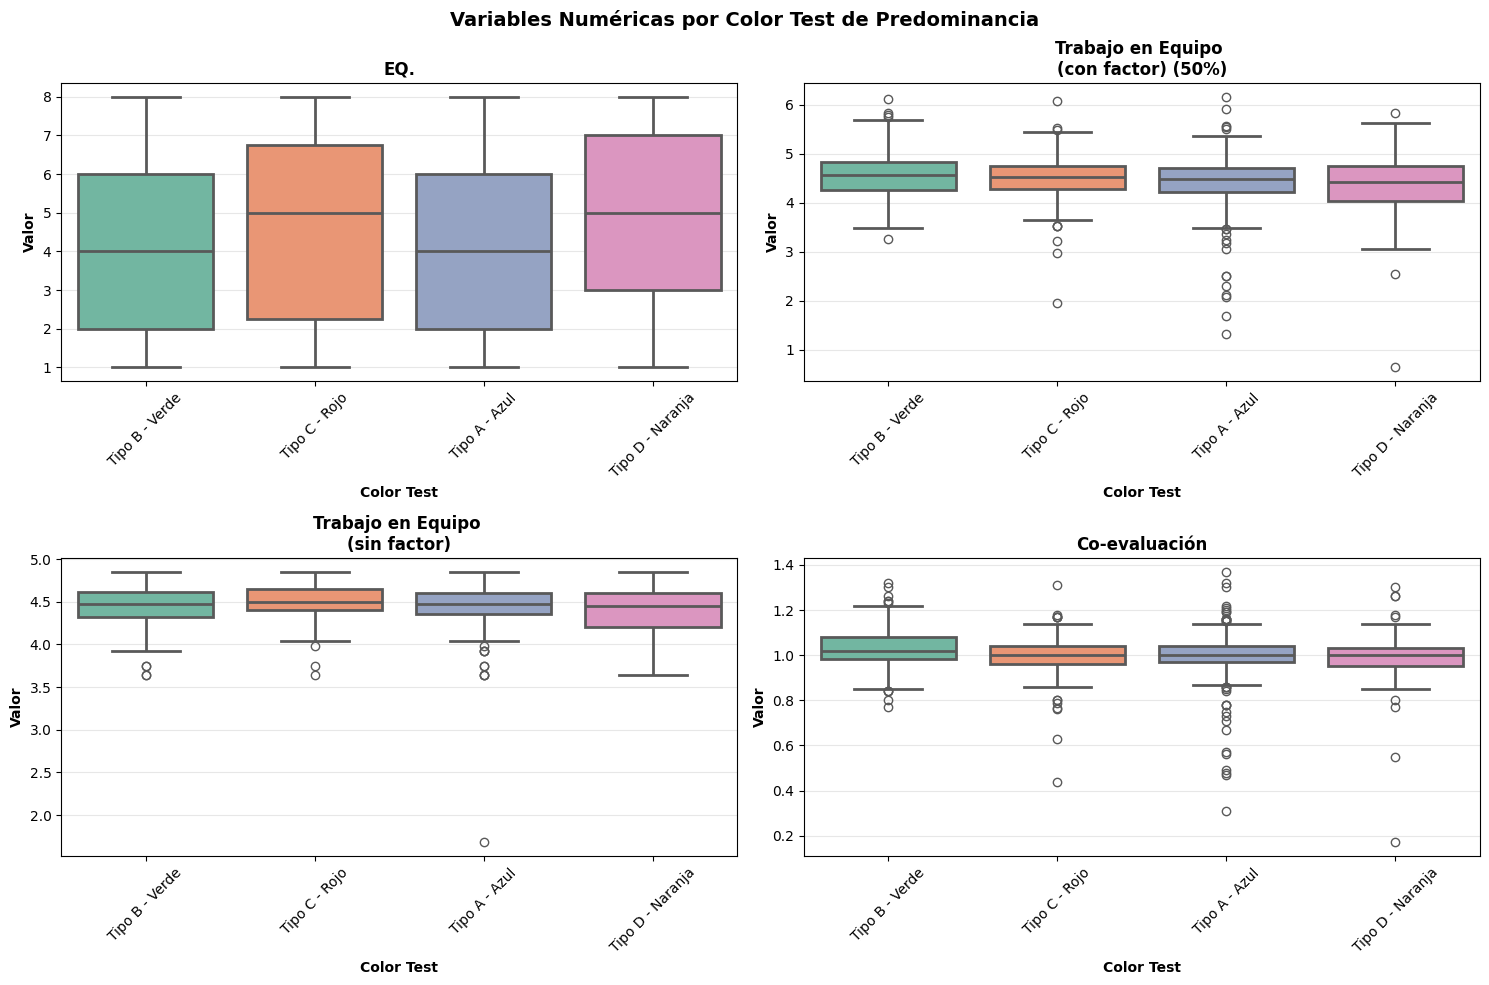

C:\Users\osqui\AppData\Local\Temp\ipykernel_11176\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_11176\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Temp\ipykernel_11176\2893191598.py:232: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='Etiqueta Semestre-Grupo', y=col, ax=ax,
C:\Users\osqui\AppData\Local\Te

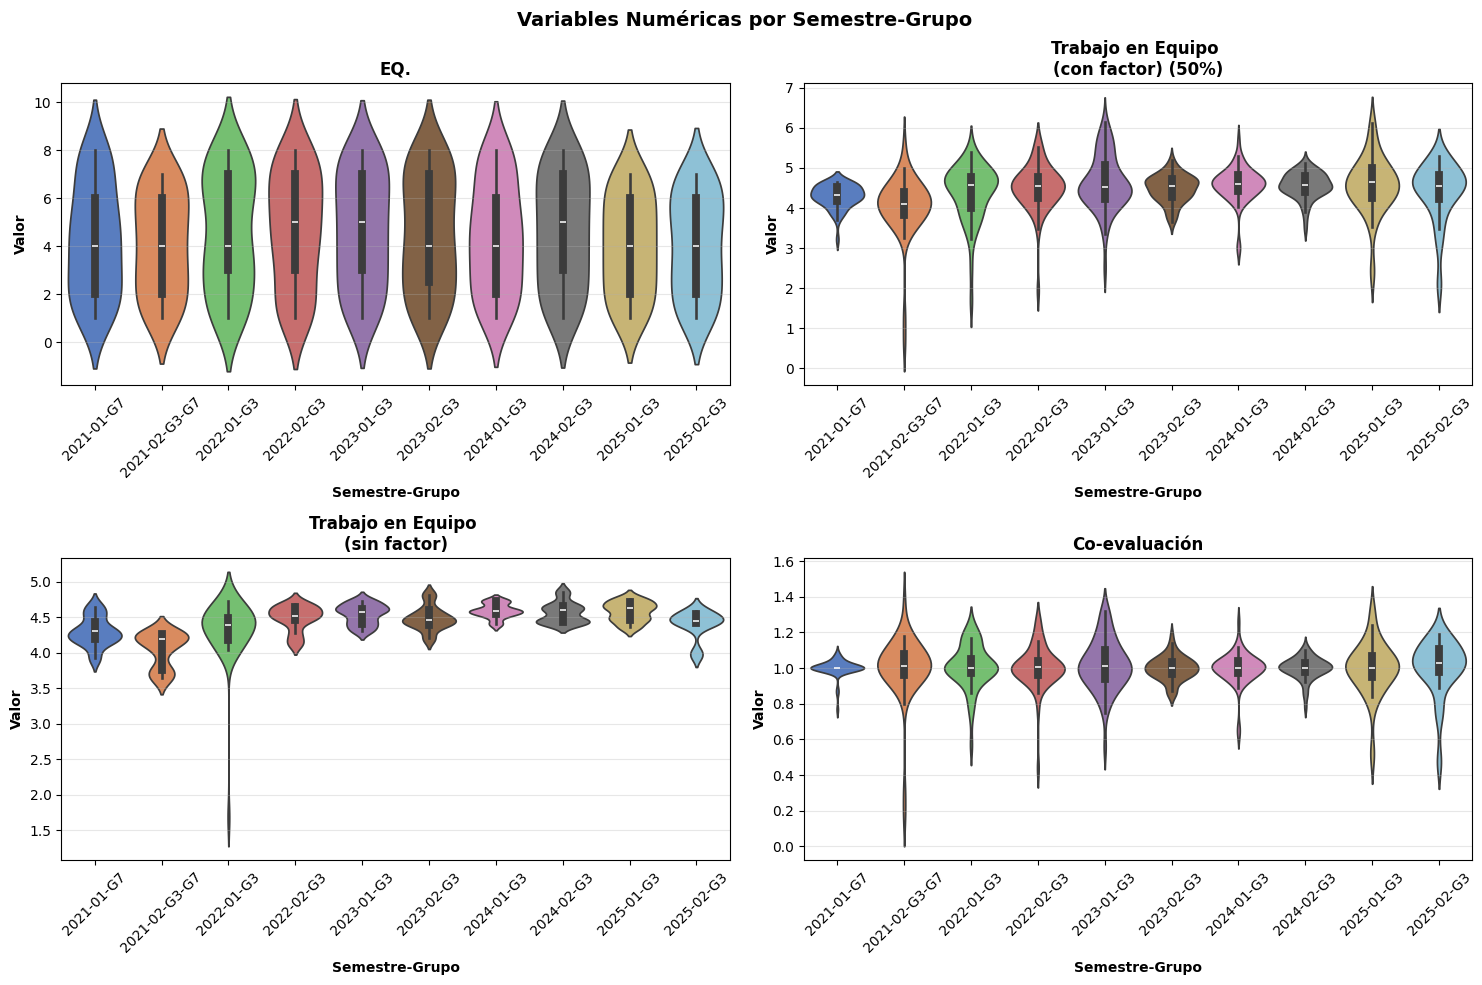

In [9]:
solo_data = dataset_raw.copy().drop(columns=['CARRERA']).set_index('ID')
EDA(solo_data)

# EDA (Grupal)

In [10]:
solo_data.columns.tolist()

['EQ.',
 'Trabajo en Equipo \n(con factor) (50%)',
 'Trabajo en Equipo \n(sin factor)',
 'Co-evaluación',
 'Color Test de predominancia',
 'Etiqueta Semestre-Grupo']

In [16]:
# Agrupación por equipo y etiqueta de semestre-grupo
# Esto calcula la cantidad de integrantes y suma el número de cada tipo de color,
# además del promedio de la nota de Trabajo en Equipo (sin factor).

grouped = solo_data.reset_index().groupby(['Etiqueta Semestre-Grupo', 'EQ.'])

integrantes = grouped.size().rename('Integrantes')
color_counts = grouped['Color Test de predominancia'].value_counts().unstack(fill_value=0)
team_score_mean = grouped['Trabajo en Equipo \n(sin factor)'].mean().rename('Promedio Trabajo en Equipo (sin factor)')

group_data = integrantes.to_frame().join(color_counts).join(team_score_mean)

group_data = pd.DataFrame(group_data[['Integrantes', 'Tipo A - Azul', 'Tipo B - Verde', 'Tipo C - Rojo', 'Tipo D - Naranja', 'Promedio Trabajo en Equipo (sin factor)']])
group_data.reset_index(inplace=True)
group_data.drop(columns=['Etiqueta Semestre-Grupo', 'EQ.', 'Integrantes'], inplace=True)
for col in group_data.columns: group_data[col] = group_data[col].astype(float)
group_data

,Tipo A - Azul,Tipo B - Verde,Tipo C - Rojo,Tipo D - Naranja,Promedio Trabajo en Equipo (sin factor)
0,4.0,1.0,1.0,1.0,4.327915
1,2.0,3.0,1.0,2.0,4.309773
2,2.0,3.0,0.0,1.0,4.194719
3,3.0,1.0,2.0,1.0,4.198635
4,4.0,2.0,0.0,1.0,4.528585
...,...,...,...,...,...
72,1.0,4.0,1.0,1.0,3.980121
73,2.0,1.0,1.0,1.0,4.478219
74,2.0,2.0,1.0,2.0,4.417172
75,4.0,2.0,1.0,0.0,4.542977


In [18]:
# CREACIÓN DE VARIABLES DERIVADAS: ANALÍTICA DE EQUIPOS Y DIVERSIDAD GRUPAL

# Nombres de columnas de tipos conductuales
TIPOS = ['Tipo A - Azul', 'Tipo B - Verde', 'Tipo C - Rojo', 'Tipo D - Naranja']

# 1. TOTAL DE INTEGRANTES
# Métrica: Suma total de integrantes del equipo
# Interpretación: Tamaño del equipo

group_data['total_integrantes'] = group_data[TIPOS].sum(axis=1)

# 2. PROPORCIONES POR TIPO
# Métrica: Proporción de cada perfil dentro del equipo
# Fórmula: cantidad_tipo / total_integrantes
# Interpretación: Peso relativo de cada perfil conductual

for tipo in TIPOS:
    nombre_columna = f'prop_{tipo.split(" - ")[1].lower()}'
    group_data[nombre_columna] = group_data[tipo] / group_data['total_integrantes']

# 3. ÍNDICE DE DIVERSIDAD DE SHANNON
# Métrica: Índice de Shannon (entropía)
# Fórmula: H = -sum(p_i * ln(p_i))
# Rango: [0, ln(k)] donde k es el número de tipos
# Interpretación:
#   - Valores altos: Mayor diversidad de perfiles
#   - Valores bajos: Menor diversidad (dominancia de pocos perfiles)

def calcular_shannon(row):
    """
    Calcula el índice de diversidad de Shannon para una fila.
    Ignora proporciones de 0 para evitar ln(0) indefinido.
    """
    proporciones = [row[f'prop_{tipo.split(" - ")[1].lower()}'] 
                    for tipo in TIPOS]
    # Filtrar valores mayores a 0 (evita ln(0) = indefinido)
    proporciones_validas = [p for p in proporciones if p > 0]
    
    if len(proporciones_validas) == 0:
        return 0
    
    shannon = -sum([p * np.log(p) for p in proporciones_validas])
    return shannon

group_data['diversidad_shannon'] = group_data.apply(calcular_shannon, axis=1)

# 4. ÍNDICE DE DOMINANCIA DEL EQUIPO
# Métrica: Proporción del perfil predominante
# Fórmula: max(cantidad_tipo) / total_integrantes
# Rango: [0, 1]
# Interpretación:
#   - Cercano a 1: Un perfil domina fuertemente el equipo (bajo balance)
#   - Cercano a 1/k (k=4): Distribución equilibrada

group_data['dominancia_equipo'] = group_data[TIPOS].max(axis=1) / group_data['total_integrantes']

# 5. CANTIDAD DE PERFILES ÚNICOS
# Métrica: Número de perfiles conductuales presentes en el equipo
# Rango: [1, 4]
# Interpretación:
#   - Valor alto: Mayor diversidad de tipos
#   - Valor bajo: Equipo con pocos tipos de perfiles

def contar_perfiles_unicos(row):
    """
    Cuenta cuántos tipos conductuales están presentes (cantidad > 0)
    en el equipo.
    """
    cantidades = [row[tipo] for tipo in TIPOS]
    return sum([1 for cant in cantidades if cant > 0])

group_data['cantidad_perfiles_unicos'] = group_data.apply(contar_perfiles_unicos, axis=1)

# 6. ÍNDICE DE BALANCE DEL EQUIPO
# Métrica: Medida de equilibrio en la distribución de perfiles
# Fórmula: 1 - std(proporciones)
# Rango: [0, 1]
# Interpretación:
#   - Cercano a 1: Distribución equilibrada (todos los perfiles representados)
#   - Cercano a 0: Distribución desbalanceada (dominancia de pocos perfiles)
# Nota: Se calcula solo con proporciones de perfiles presentes (> 0)

def calcular_balance(row):
    """
    Calcula el índice de balance como 1 - desviación estándar
    de las proporciones de perfiles presentes.
    """
    proporciones = [row[f'prop_{tipo.split(" - ")[1].lower()}'] 
                    for tipo in TIPOS]
    proporciones_validas = [p for p in proporciones if p > 0]
    
    if len(proporciones_validas) <= 1:
        # Si hay solo un perfil o ninguno, balance es 0
        return 0
    
    desv_est = np.std(proporciones_validas)
    balance = 1 - desv_est
    
    return balance

group_data['balance_equipo'] = group_data.apply(calcular_balance, axis=1)

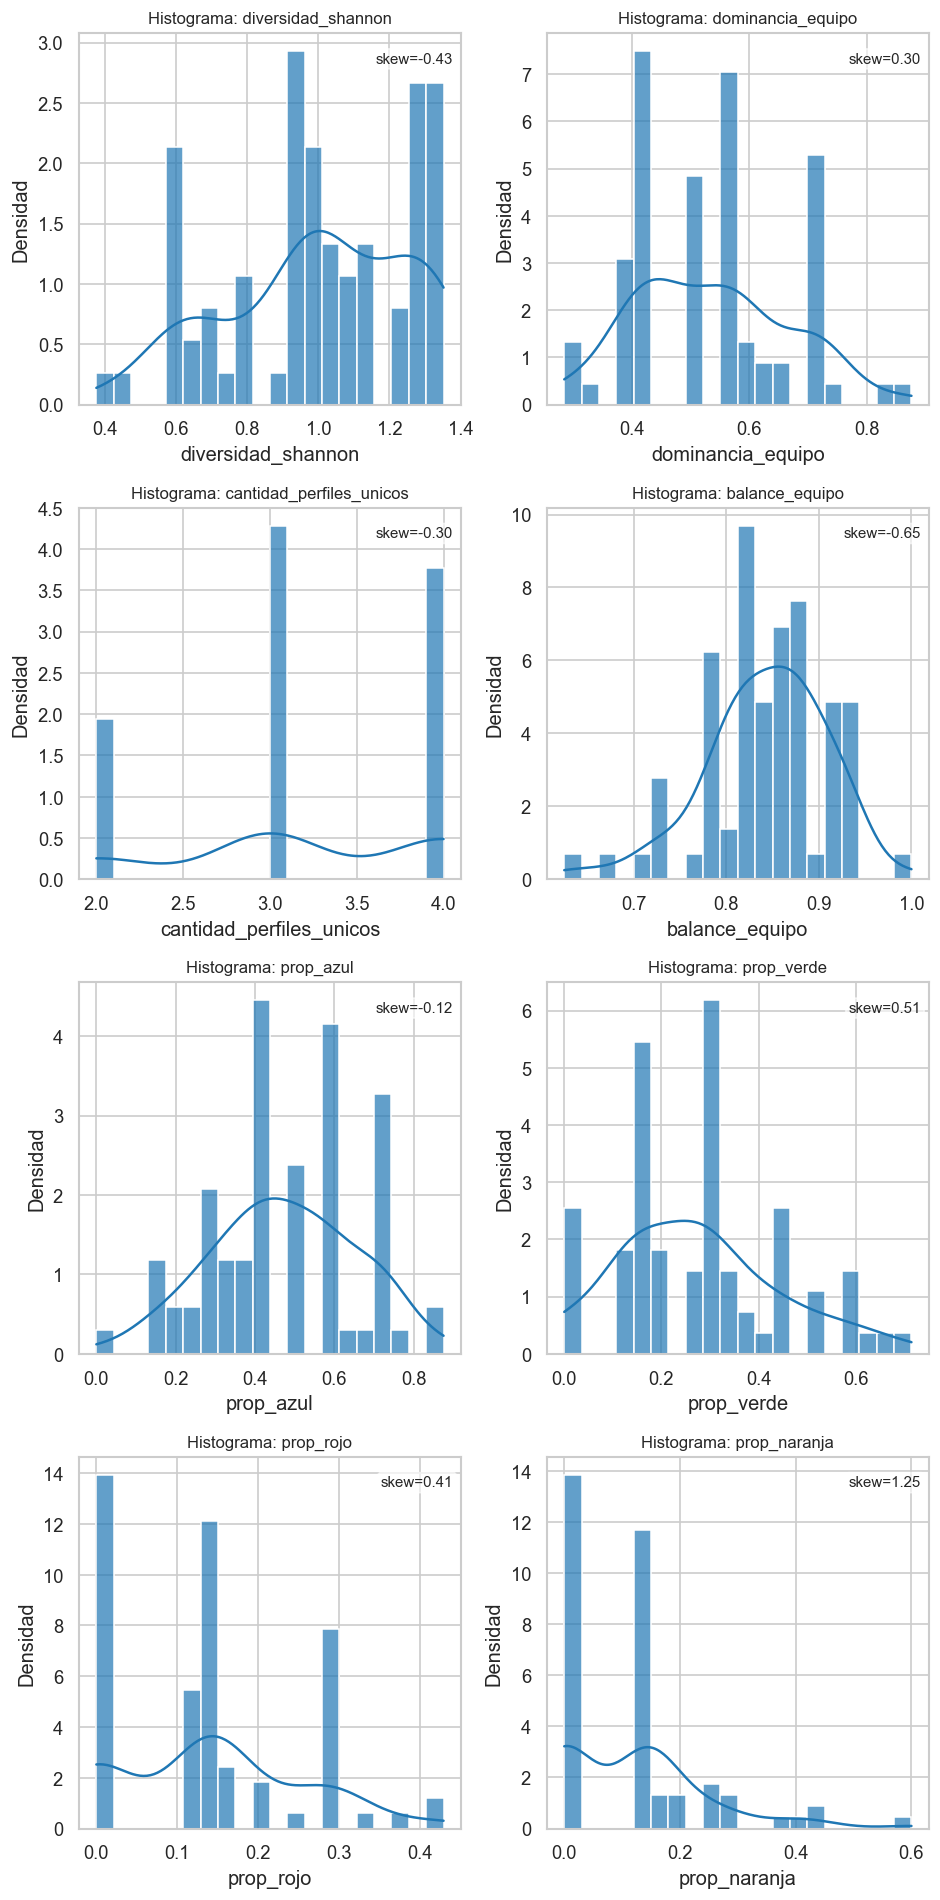

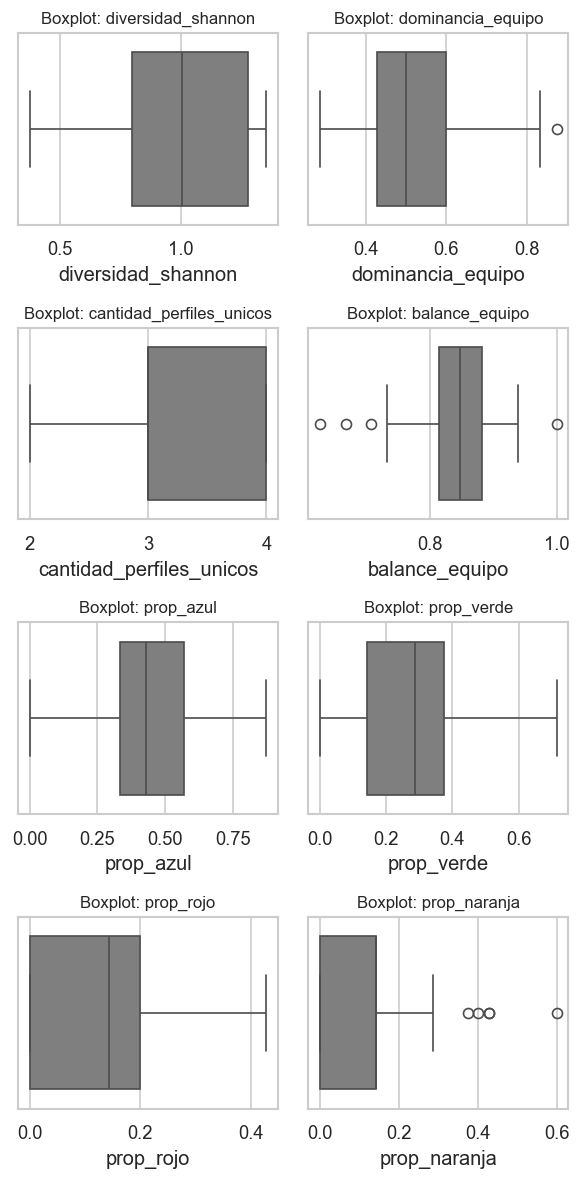

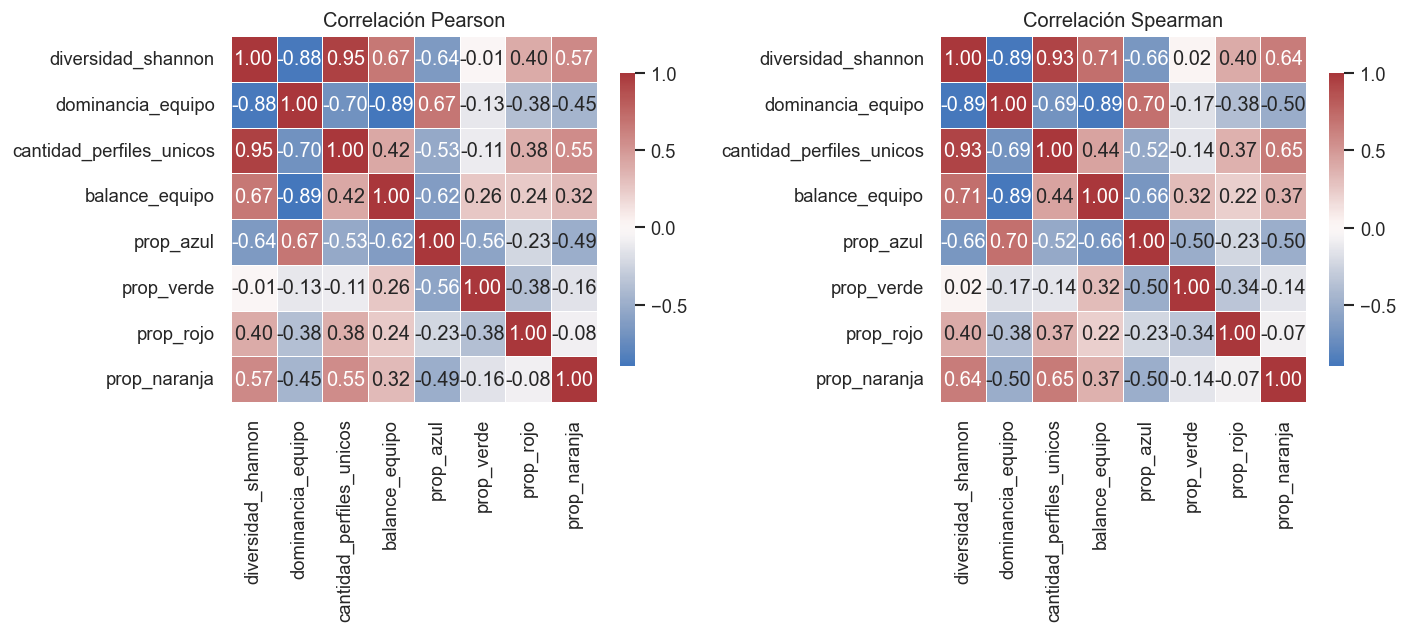

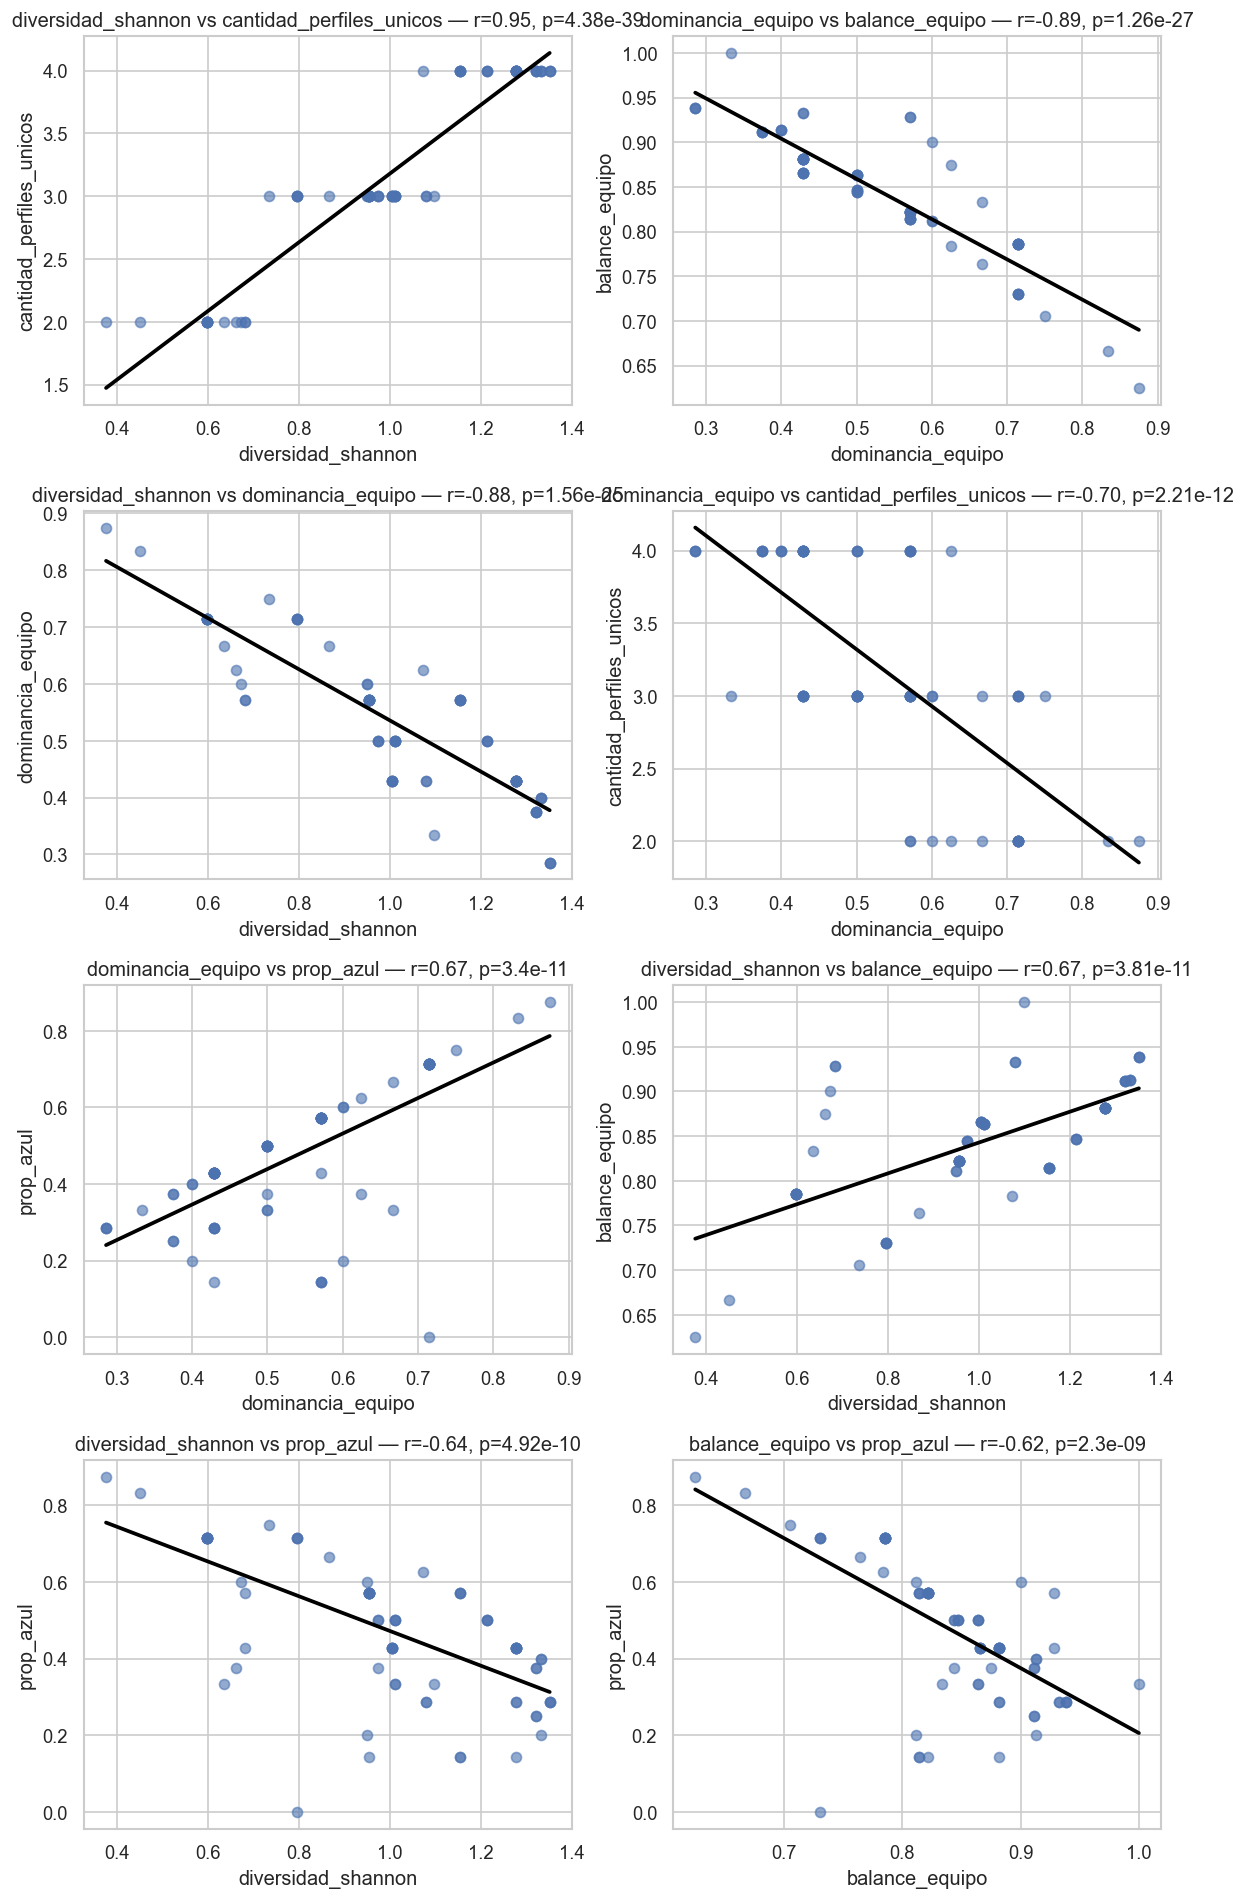

In [22]:
import itertools

sns.set(style="whitegrid", context="notebook", rc={"figure.dpi": 120})

def compute_descriptive_statistics(df, variables):
    """
    Calcula estadísticos descriptivos para una lista de variables.
    Devuelve DataFrame con: mean, median, std, min, max, Q1, Q3, IQR, skewness, kurtosis.
    """
    records = []
    for var in variables:
        if var not in df.columns:
            continue
        s = df[var].dropna().astype(float)
        n = s.size
        if n == 0:
            continue
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        rec = {
            "variable": var,
            "n": n,
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(ddof=1),
            "min": s.min(),
            "max": s.max(),
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            # scipy.stats.skew/kurtosis manejan NaNs internamente con nan_policy
            "skewness": float(stats.skew(s, nan_policy="omit")),
            "kurtosis": float(stats.kurtosis(s, fisher=False, nan_policy="omit"))  # Pearson kurtosis
        }
        records.append(rec)
    stats_df = pd.DataFrame.from_records(records).set_index("variable")
    return stats_df

def plot_histograms(df, variables, bins=20, kde=True, figsize_per=4):
    """
    Histogramas individuales con KDE opcional. Cierra figuras al final.
    """
    n = len(variables)
    cols = 2 if n > 1 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per, rows*figsize_per))
    axes = np.array(axes).reshape(-1)
    for ax, var in zip(axes, variables):
        data = df[var].dropna().astype(float)
        if data.size < 2:
            ax.text(0.5, 0.5, f"No hay suficientes datos para {var}", ha="center")
            ax.set_axis_off()
            continue
        sns.histplot(data, bins=bins, kde=kde, stat="density", ax=ax,
                     color="tab:blue", edgecolor="w", alpha=0.7)
        ax.set_title(f"Histograma: {var}", fontsize=10)
        ax.set_xlabel(var)
        ax.set_ylabel("Densidad")
        skewness = float(stats.skew(data, nan_policy="omit"))
        ax.annotate(f"skew={skewness:.2f}", xy=(0.98, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=9, bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
    # hide unused axes
    for ax in axes[len(variables):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_boxplots(df, variables, figsize_per=2.5):
    """
    Boxplots individuales para cada variable (una por subplot).
    """
    n = len(variables)
    cols = 2 if n > 1 else 1
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per, rows*figsize_per))
    axes = np.array(axes).reshape(-1)
    for ax, var in zip(axes, variables):
        data = df[var].dropna().astype(float)
        if data.size == 0:
            ax.text(0.5, 0.5, f"No hay datos para {var}", ha="center")
            ax.set_axis_off()
            continue
        sns.boxplot(x=data, ax=ax, color="tab:gray")
        ax.set_title(f"Boxplot: {var}", fontsize=10)
        ax.set_xlabel(var)
    for ax in axes[len(variables):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_correlation_heatmaps(df, variables, cmap="vlag"):
    """
    Calcula y muestra heatmaps de correlación Pearson y Spearman con anotaciones.
    """
    subdf = df[variables].astype(float).copy()
    pearson = subdf.corr(method="pearson")
    spearman = subdf.corr(method="spearman")

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(pearson, annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax[0],
                cbar_kws={"shrink": .8}, square=True, linewidths=.5)
    ax[0].set_title("Correlación Pearson")

    sns.heatmap(spearman, annot=True, fmt=".2f", cmap=cmap, center=0, ax=ax[1],
                cbar_kws={"shrink": .8}, square=True, linewidths=.5)
    ax[1].set_title("Correlación Spearman")

    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return pearson, spearman


def plot_scatter_top_pairs(df, variables, top_n=8, alpha=0.6):
    """
    Grafica scatter + línea de tendencia para los pares con mayor correlación absoluta (Pearson).
    Limita a top_n pares para mantener la visualización manejable.
    Muestra coeficiente Pearson y p-value en el título.
    """
    subdf = df[variables].astype(float).copy()
    corr = subdf.corr(method="pearson").abs()
    # crear lista de pares (i,j) i<j con su correlación absoluta
    pairs = []
    cols = corr.columns.tolist()
    for i, j in itertools.combinations(cols, 2):
        val = corr.loc[i, j]
        pairs.append((i, j, val))
    pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)
    selected = pairs_sorted[:top_n]
    n = len(selected)
    cols_plot = 2 if n > 1 else 1
    rows_plot = int(np.ceil(n / cols_plot)) if n>0 else 0
    if n == 0:
        print("No hay pares suficientes para graficar.")
        return
    fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(cols_plot*5, rows_plot*4))
    axes = np.array(axes).reshape(-1)
    for ax, (xvar, yvar, corr_val) in zip(axes, selected):
        x = subdf[xvar].dropna()
        y = subdf[yvar].dropna()
        # align indices para evitar mismatched lengths
        inter = subdf[[xvar, yvar]].dropna()
        if inter.shape[0] < 3:
            ax.text(0.5, 0.5, f"No hay suficientes puntos para {xvar} vs {yvar}", ha="center")
            ax.set_axis_off()
            continue
        sns.regplot(x=xvar, y=yvar, data=inter, scatter_kws={"alpha": alpha}, ax=ax,
                    line_kws={"color":"black"}, scatter=True, ci=None)
        r, p = stats.pearsonr(inter[xvar], inter[yvar])
        ax.set_title(f"{xvar} vs {yvar} — r={r:.2f}, p={p:.3g}")
        ax.set_xlabel(xvar)
        ax.set_ylabel(yvar)
    for ax in axes[len(selected):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def eda_group_composition(df, variables, top_scatter_pairs=8):
    """
    Función principal que ejecuta el EDA solicitado sobre `variables` en `df`.
    Retorna: (stats_df, pearson_matrix, spearman_matrix)
    """
    # Validación simple
    variables = [v for v in variables if v in df.columns]
    if len(variables) == 0:
        raise ValueError("Ninguna de las variables solicitadas existe en el DataFrame.")

    # Estadísticos descriptivos
    stats_df = compute_descriptive_statistics(df, variables)

    # Visualizaciones
    plot_histograms(df, variables, bins=20, kde=True)
    plot_boxplots(df, variables)
    pearson, spearman = plot_correlation_heatmaps(df, variables)
    plot_scatter_top_pairs(df, variables, top_n=top_scatter_pairs)

    # Mostrar resumen y devolver objetos
    
    return stats_df, pearson, spearman

# -----------------------
# Uso: ejecutar esta celda en el notebook donde `group_data` ya existe.
# Lista de variables objetivo (ajustar si es necesario)
vars_target = [
    'diversidad_shannon',
    'dominancia_equipo',
    'cantidad_perfiles_unicos',
    'balance_equipo',
    'prop_azul',
    'prop_verde',
    'prop_rojo',
    'prop_naranja'
]

# Ejecutar EDA. La función muestra figuras y devuelve tablas para inspección adicional.
stats_df, pearson_matrix, spearman_matrix = eda_group_composition(group_data, vars_target, top_scatter_pairs=8)
